<a href="https://colab.research.google.com/github/DhritiKothari/Handwriting-Analysis/blob/main/handwriting_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
BASE_DIR = "/content/drive/MyDrive/handwriting_dataset/000"
print(os.listdir(BASE_DIR)[:10])

['a01-000u.png', 'a01-003u.png', 'a01-007u.png', 'a01-011u.png', 'a01-014u.png', 'a01-026u.png', 'a01-020u.png', 'a01-030u.png', 'a01-043u.png', 'a01-068u.png']


In [ ]:
def is_image(filename):
    return filename.lower().endswith(('.jpg', '.jpeg', '.png'))

image_files = [f for f in os.listdir(BASE_DIR) if is_image(f)]

print("Total images in 000:", len(image_files))
print(image_files[:5])


Total images in 000: 60
['a01-000u.png', 'a01-003u.png', 'a01-007u.png', 'a01-011u.png', 'a01-014u.png']


In [ ]:
img_name = image_files[0]
img_path = os.path.join(BASE_DIR, img_name)

print(img_path)


/content/drive/MyDrive/handwriting_dataset/000/a01-000u.png


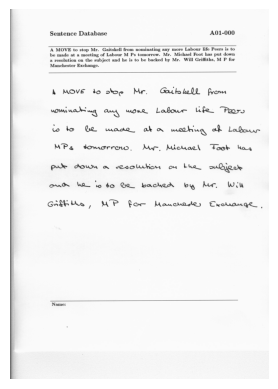

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)

if img is None:
    print("Failed to load image")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/handwriting_dataset"

all_images = []

for folder in os.listdir(DATASET_ROOT):
    folder_path = os.path.join(DATASET_ROOT, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(folder_path, file))

print("Total images found:", len(all_images))
print(all_images[:3])


Total images found: 1340
['/content/drive/MyDrive/handwriting_dataset/000/a01-000u.png', '/content/drive/MyDrive/handwriting_dataset/000/a01-003u.png', '/content/drive/MyDrive/handwriting_dataset/000/a01-007u.png']


In [ ]:
import cv2
import numpy as np
import os

# Create output folder
PREPROCESS_DIR = "/content/preprocessed_images"
os.makedirs(PREPROCESS_DIR, exist_ok=True)

for img_path in all_images:
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Thresholding
    _, binary = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Noise removal
    kernel = np.ones((3,3), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Save with same filename
    filename = os.path.basename(img_path)
    save_path = os.path.join(PREPROCESS_DIR, filename)
    cv2.imwrite(save_path, cleaned)

print("✅ Preprocessing completed for all images.")


✅ Preprocessing completed for all images.


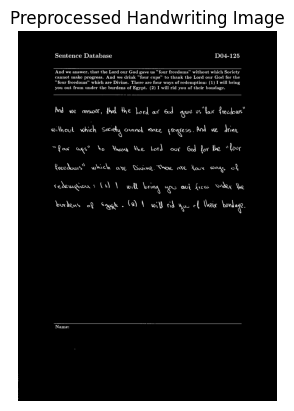

In [ ]:
import matplotlib.pyplot as plt

test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

img = cv2.imread(test_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Preprocessed Handwriting Image")
plt.axis("off")
plt.show()


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"

def extract_slant(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    edges = cv2.Canny(img, 50, 150, apertureSize=3)

    lines = cv2.HoughLines(edges, 1, np.pi / 180, 150)
    if lines is None:
        return 0  # no lines detected

    angles = []
    for line in lines[:20]:  # limit for speed
        rho, theta = line[0]
        angle = (theta - np.pi / 2) * (180 / np.pi)
        angles.append(angle)

    return np.mean(angles)


In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

slant_value = extract_slant(test_path)
print("Slant angle:", slant_value)


Slant angle: 0.0


In [ ]:
slant_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    slant = extract_slant(img_path)
    slant_features.append([img_name, slant])

print("Slant extracted for", len(slant_features), "images")


Slant extracted for 1340 images


In [ ]:
import pandas as pd

slant_df = pd.DataFrame(slant_features, columns=["image", "slant"])
slant_df.to_csv("/content/slant_features.csv", index=False)

print("Saved slant_features.csv")


Saved slant_features.csv


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"

def extract_baseline(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Get coordinates of text pixels
    ys, xs = np.where(img > 0)

    if len(xs) == 0:
        return 0

    # For each column, take the lowest text pixel
    baseline_points = {}
    for x, y in zip(xs, ys):
        if x not in baseline_points or y > baseline_points[x]:
            baseline_points[x] = y

    x_vals = np.array(list(baseline_points.keys()))
    y_vals = np.array(list(baseline_points.values()))

    if len(x_vals) < 2:
        return 0

    # Fit a line y = mx + c
    slope, _ = np.polyfit(x_vals, y_vals, 1)

    return slope


In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

baseline_value = extract_baseline(test_path)
print("Baseline slope:", baseline_value)


Baseline slope: 0.0013764750945783558


In [ ]:
baseline_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    baseline = extract_baseline(img_path)
    baseline_features.append([img_name, baseline])

print("Baseline extracted for", len(baseline_features), "images")


Baseline extracted for 1340 images


In [ ]:
import pandas as pd

baseline_df = pd.DataFrame(baseline_features, columns=["image", "baseline"])
baseline_df.to_csv("/content/baseline_features.csv", index=False)

print("Saved baseline_features.csv")


Saved baseline_features.csv


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"

def extract_word_spacing(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Find connected components (words)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        img, connectivity=8
    )

    # Extract bounding boxes of components (ignore tiny noise)
    boxes = []
    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        if area > 50:  # threshold to remove noise
            boxes.append((x, y, w, h))

    if len(boxes) < 2:
        return 0

    # Sort boxes left to right
    boxes = sorted(boxes, key=lambda b: b[0])

    # Compute spacing between consecutive boxes
    spacings = []
    for i in range(len(boxes) - 1):
        x1, _, w1, _ = boxes[i]
        x2, _, _, _ = boxes[i + 1]
        gap = x2 - (x1 + w1)
        if gap > 0:
            spacings.append(gap)

    if len(spacings) == 0:
        return 0

    return np.mean(spacings)


In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

spacing_value = extract_word_spacing(test_path)
print("Average word spacing:", spacing_value)


Average word spacing: 2.6666666666666665


In [ ]:
spacing_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    spacing = extract_word_spacing(img_path)
    spacing_features.append([img_name, spacing])

print("Word spacing extracted for", len(spacing_features), "images")


Word spacing extracted for 1340 images


In [ ]:
import pandas as pd

spacing_df = pd.DataFrame(spacing_features, columns=["image", "spacing"])
spacing_df.to_csv("/content/spacing_features.csv", index=False)

print("Saved spacing_features.csv")


Saved spacing_features.csv


In [ ]:
import cv2
import numpy as np
import os

PREPROCESS_DIR = "/content/preprocessed_images"

def extract_stroke_thickness(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Ensure binary (white strokes on black)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY)

    # Invert for distance transform
    binary_inv = cv2.bitwise_not(binary)

    # Distance transform
    dist = cv2.distanceTransform(binary_inv, cv2.DIST_L2, 5)

    # Stroke thickness ≈ 2 × mean distance
    thickness = 2 * np.mean(dist[dist > 0])

    return thickness


In [ ]:
test_img = os.listdir(PREPROCESS_DIR)[0]
test_path = os.path.join(PREPROCESS_DIR, test_img)

stroke_value = extract_stroke_thickness(test_path)
print("Stroke thickness:", stroke_value)


Stroke thickness: 408.6268


In [ ]:
stroke_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    stroke = extract_stroke_thickness(img_path)
    stroke_features.append([img_name, stroke])

print("Stroke thickness extracted for", len(stroke_features), "images")


Stroke thickness extracted for 1340 images


In [ ]:
import pandas as pd

stroke_df = pd.DataFrame(stroke_features, columns=["image", "stroke"])
stroke_df.to_csv("/content/stroke_features.csv", index=False)

print("Saved stroke_features.csv")


Saved stroke_features.csv


In [ ]:
import pandas as pd

slant_df = pd.read_csv("/content/slant_features.csv")
baseline_df = pd.read_csv("/content/baseline_features.csv")
spacing_df = pd.read_csv("/content/spacing_features.csv")
stroke_df = pd.read_csv("/content/stroke_features.csv")

print(slant_df.head())


         image  slant
0  d04-125.png   0.00
1  e04-095.png  -4.50
2  r03-035.png   0.00
3  p03-072.png  -9.05
4  d06-041.png  -4.55


In [ ]:
features_df = slant_df \
    .merge(baseline_df, on="image") \
    .merge(spacing_df, on="image") \
    .merge(stroke_df, on="image")

features_df.head()


,image,slant,baseline,spacing,stroke
0,d04-125.png,0.00,0.001376,2.666667,408.62680
1,e04-095.png,-4.50,-0.078234,58.166667,330.85306
2,r03-035.png,0.00,-0.080727,157.000000,320.43433
3,p03-072.png,-9.05,-0.035333,163.000000,323.00970
4,d06-041.png,-4.55,0.040703,102.400000,310.95474


In [ ]:
features_df.isnull().sum()


,0
image,0
slant,0
baseline,0
spacing,0
stroke,0


In [ ]:
features_df = features_df.fillna(0)


In [ ]:
features_df.to_csv("/content/handwriting_features.csv", index=False)

print("✅ Final feature dataset saved as handwriting_features.csv")


✅ Final feature dataset saved as handwriting_features.csv


In [ ]:
import pandas as pd
import numpy as np

# Load feature dataset
df = pd.read_csv("/content/handwriting_features.csv")

df.head()


,image,slant,baseline,spacing,stroke
0,d04-125.png,0.00,0.001376,2.666667,408.62680
1,e04-095.png,-4.50,-0.078234,58.166667,330.85306
2,r03-035.png,0.00,-0.080727,157.000000,320.43433
3,p03-072.png,-9.05,-0.035333,163.000000,323.00970
4,d06-041.png,-4.55,0.040703,102.400000,310.95474


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['slant', 'spacing', 'stroke']] = scaler.fit_transform(
    df[['slant', 'spacing', 'stroke']]
)


In [ ]:
def assign_personality(row):
    score = 0

    # Slant
    if row['slant'] > 0.5:
        score += 1
    else:
        score -= 1

    # Spacing
    if row['spacing'] < 0.5:
        score += 1
    else:
        score -= 1

    # Stroke
    if row['stroke'] > 0.5:
        score += 1
    else:
        score -= 1

    return "Extrovert" if score >= 1 else "Introvert"




In [ ]:
df['personality'] = df.apply(assign_personality, axis=1)

df['personality'].value_counts()


,count
personality,
Extrovert,1175
Introvert,165


In [ ]:
df.to_csv("/content/handwriting_labeled_dataset.csv", index=False)

print("✅ Labeled dataset saved")


✅ Labeled dataset saved


In [ ]:
import pandas as pd

df = pd.read_csv("/content/handwriting_labeled_dataset.csv")

# Features and target
X = df[['slant', 'baseline', 'spacing', 'stroke']]
y = df['personality']

print(y.value_counts())


personality
Extrovert    1175
Introvert     165
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Extrovert': np.int64(0), 'Introvert': np.int64(1)}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'  # 🔥 THIS IS THE ADJUSTMENT
)

model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Confusion Matrix:
 [[235   0]
 [  0  33]]

Classification Report:

              precision    recall  f1-score   support

   Extrovert       1.00      1.00      1.00       235
   Introvert       1.00      1.00      1.00        33

    accuracy                           1.00       268
   macro avg       1.00      1.00      1.00       268
weighted avg       1.00      1.00      1.00       268



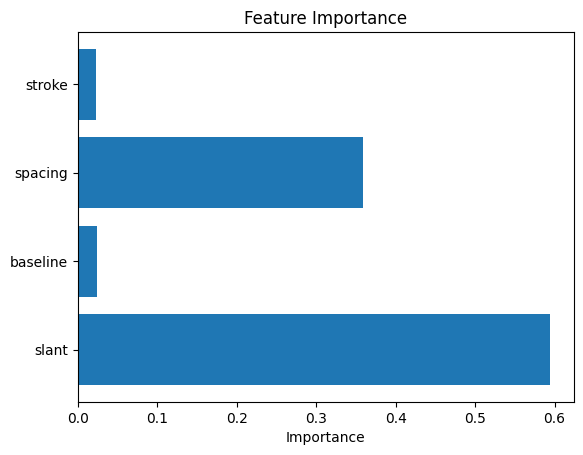

In [ ]:
import matplotlib.pyplot as plt
importances = model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()
